<p align="center">
  <img src="https://i0.wp.com/www.tiempodecine.co/web/wp-content/uploads/2015/11/Robert-De-Niro-in-Taxi-Driver-1976.jpg?resize=750%2C375&ssl=1" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Clustering de Zonas para Optimización de Flotas</span>
  </p>
</div>

# FASE 4: Modelado (CRISP-DM)

## Propósito de la Fase de Modelado

En esta cuarta fase del proceso CRISP-DM, aplicamos **algoritmos de Clustering (Aprendizaje No Supervisado)** para:

### **Problema de Negocio:**
- Identificar zonas con patrones de demanda similares
- Optimizar la distribución de taxis y vehículos de alquiler
- Mejorar la planificación de recursos

### **Enfoque de Modelado:**
1. **K-Means**: Clustering particional rápido y escalable
2. **DBSCAN**: Para identificar clusters de forma arbitraria y outliers
3. **Clustering Jerárquico**: Para analizar relaciones jerárquicas entre zonas

### **Métricas de Evaluación:**
- **Silhouette Score**: Cohesión y separación de clusters
- **Davies-Bouldin Index**: Similaridad entre clusters
- **Calinski-Harabasz Score**: Ratio de dispersión entre/dentro clusters

# 1. Carga de Librerías

In [33]:
# Verificar e instalar dependencias
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')
    
    # Librerías base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import joblib
    import json
    from pathlib import Path
    
    # Machine Learning
    from sklearn.preprocessing import StandardScaler, MinMaxScaler
    from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
    from scipy.cluster.hierarchy import dendrogram, linkage
    from scipy.spatial.distance import cdist
    
    print("✓ Todas las dependencias cargadas exitosamente")
    
except ImportError as e:
    print(f"Instalando dependencias faltantes...")
    %pip install --quiet scikit-learn scipy matplotlib seaborn joblib
    print("✓ Instalación completada")

✓ Todas las dependencias cargadas exitosamente


# 2. Configuración

In [34]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Crear directorio para modelos si no existe
Path('models').mkdir(exist_ok=True)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Configuración completada")

✓ Configuración completada


# 3. Carga de Datos Preparados

## Datos Pre-procesados de Data Preparation

En este notebook utilizamos los **datos ya normalizados** que fueron preparados en la Fase 3:

### **Archivos Disponibles desde Data Preparation:**
- `zone_features_raw.parquet` - Features sin normalizar
- `zone_features_clustering.parquet` - Features seleccionadas sin normalizar  
- **`zone_features_scaled.parquet`** - **Features normalizadas con RobustScaler** ⭐
- `robust_scaler.pkl` - Modelo de normalización usado

### **Ventajas de usar datos ya preparados:**
1. **Consistencia**: Mismo scaler (RobustScaler) aplicado a todos los datos
2. **Eficiencia**: No duplicamos el trabajo de normalización 
3. **Robustez**: RobustScaler maneja outliers mejor que StandardScaler
4. **Trazabilidad**: Mantenemos coherencia entre fases del proceso

### **Nota Importante:**
No aplicamos normalización adicional en esta fase - los datos ya están optimizados para clustering.

In [35]:
# Cargar dataset agregado por zonas
print("="*60)
print("CARGANDO DATOS PREPARADOS")
print("="*60)

# Cargar el dataset ya normalizado desde Data Preparation
data_file = './data/DataPreparation_zone_features.parquet'

try:
    zones_scaled_df = pd.read_parquet(data_file)
    
    print(f"✓ Datos normalizados cargados exitosamente")
    print(f"  Archivo: {data_file}")
    print(f"  Shape: {zones_scaled_df.shape}")
    print(f"  Número de zonas: {len(zones_scaled_df)}")
    
    # Verificar que zone_id está presente
    if 'zone_id' not in zones_scaled_df.columns:
        print("⚠  WARNING: zone_id no encontrado, usando índice como identificador")
        zones_scaled_df['zone_id'] = zones_scaled_df.index
    
    print(f"\nColumnas disponibles ({len(zones_scaled_df.columns)}):")
    for i, col in enumerate(zones_scaled_df.columns, 1):
        print(f"  {i:2d}. {col}")
        
    # Seleccionar solo features numéricas válidas para clustering
    feature_cols = [col for col in zones_scaled_df.columns 
                   if col not in ['zone_id', 'total_data_length'] and zones_scaled_df[col].dtype in ['float64', 'int64']]
    
    print(f"\nFeatures seleccionadas para clustering ({len(feature_cols)}):")
    for i, col in enumerate(feature_cols, 1):
        print(f"  {i:2d}. {col}")


except FileNotFoundError:
    print(f"Error: No se pudo encontrar el archivo {data_file}")
    print("   Asegúrese de que el archivo existe en la carpeta data_prep/")
except Exception as e:
    print(f"Error al cargar datos: {str(e)}")


CARGANDO DATOS PREPARADOS
✓ Datos normalizados cargados exitosamente
  Archivo: ./data/DataPreparation_zone_features.parquet
  Shape: (248, 24)
  Número de zonas: 248

Columnas disponibles (24):
   1. zone_id
   2. total_trips
   3. avg_pickup_hour
   4. std_pickup_hour
   5. avg_day_of_week
   6. avg_trip_distance
   7. std_trip_distance
   8. median_trip_distance
   9. avg_trip_duration
  10. avg_fare
  11. std_fare
  12. avg_total_amount
  13. std_total_amount
  14. avg_tip
  15. avg_tolls
  16. avg_color_taxi
  17. peak_hour
  18. peak_hour_concentration_pct
  19. pct_AM_Peak
  20. pct_Early_Morning
  21. pct_OP_day
  22. pct_OP_night
  23. pct_PM_Peak
  24. pct_weekend_trips

Features seleccionadas para clustering (23):
   1. total_trips
   2. avg_pickup_hour
   3. std_pickup_hour
   4. avg_day_of_week
   5. avg_trip_distance
   6. std_trip_distance
   7. median_trip_distance
   8. avg_trip_duration
   9. avg_fare
  10. std_fare
  11. avg_total_amount
  12. std_total_amount
  13. 

In [36]:
# Mostrar primeras filas
print("\nPrimeras filas del dataset normalizado:")
display(zones_scaled_df.sample(5).round(2))


Primeras filas del dataset normalizado:


,zone_id,total_trips,avg_pickup_hour,std_pickup_hour,avg_day_of_week,avg_trip_distance,std_trip_distance,median_trip_distance,avg_trip_duration,avg_fare,std_fare,avg_total_amount,std_total_amount,avg_tip,avg_tolls,avg_color_taxi,peak_hour,peak_hour_concentration_pct,pct_AM_Peak,pct_Early_Morning,pct_OP_day,pct_OP_night,pct_PM_Peak,pct_weekend_trips
33,-1.270,-0.340,-0.410,1.310,1.180,-0.130,-0.170,-0.050,0.420,-0.010,-0.360,-0.120,-0.490,-0.410,-0.020,0.590,-1.680,-0.600,-0.120,1.250,-0.990,0.360,0.010,1.380
6,-1.630,-0.580,-0.620,0.130,-0.350,-0.130,-0.170,0.000,-0.410,-0.220,-0.420,-0.330,-0.700,-0.750,-0.520,-0.980,-1.510,-0.250,0.670,0.170,-0.370,-1.340,0.930,-0.810
182,0.810,-0.420,-0.590,0.190,0.080,-0.150,-0.170,-0.780,-0.810,-0.090,1.420,-0.320,1.650,0.230,-0.110,0.020,-0.510,-0.230,0.580,0.280,-0.100,-0.460,-0.480,-0.070
86,-0.560,0.170,0.400,0.740,0.100,0.350,0.750,-0.730,0.480,0.880,2.980,0.360,2.810,0.430,-0.400,-1.250,0.990,-0.680,-0.450,0.260,-0.490,0.570,0.580,0.130
156,0.460,1.760,0.900,-0.410,-0.420,-0.170,-0.170,-0.900,-0.960,-0.550,-0.120,-0.660,-0.030,0.470,-0.370,1.620,0.990,-0.580,-0.450,-0.620,0.040,0.210,1.140,-0.330


In [37]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(zones_scaled_df.describe().round(2).T)


Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
zone_id,248.000,-0.000,1.000,-1.740,-0.880,0.040,0.870,1.700
total_trips,248.000,-0.000,1.000,-0.590,-0.550,-0.480,0.100,4.540
avg_pickup_hour,248.000,-0.000,1.000,-2.940,-0.620,0.020,0.690,2.590
std_pickup_hour,248.000,0.000,1.000,-3.540,-0.510,0.050,0.570,2.830
avg_day_of_week,248.000,0.000,1.000,-3.170,-0.470,-0.070,0.350,3.150
avg_trip_distance,248.000,0.000,1.000,-0.180,-0.160,-0.140,-0.110,8.970
std_trip_distance,248.000,0.000,1.000,-0.170,-0.170,-0.170,-0.160,8.550
median_trip_distance,248.000,-0.000,1.000,-1.360,-0.750,-0.290,0.300,3.760
avg_trip_duration,248.000,-0.000,1.000,-1.830,-0.810,-0.170,0.550,3.620
avg_fare,248.000,-0.000,1.000,-1.600,-0.570,-0.320,0.170,4.140


# 4. Uso de Features Ya Preparadas

Utilizamos el dataset que ya fue normalizado en la Fase 3 (Data Preparation) con StandardScaler.

In [55]:
# Preparar matriz de features normalizadas para clustering
X_scaled = zones_scaled_df[feature_cols].values

# Verificación detallada de datos normalizados
print("\nVerificando estado de normalización:")
print(f"✓ Features ya normalizadas usando StandardScaler en Data Preparation")
print(f"  Media promedio de features: {X_scaled.mean():.6f}")
print(f"  Desviación estándar promedio: {X_scaled.std():.6f}")
print(f"  Rango de datos: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")

# Verificar distribución de los datos
print(f"\nDistribución de datos normalizados:")

percentiles = np.percentile(X_scaled.flatten(), [5, 25, 50, 75, 95])
print("\n✓ Datos listos para clustering (sin normalización adicional necesaria)")

print(f"  Percentiles [5%, 25%, 50%, 75%, 95%]: {percentiles}")# Nota: No es necesario guardar un nuevo scaler ya que se usó RobustScaler en Data Preparation



# Detectar valores extremos que pueden afectar visualizaciones
extreme_count = np.sum(np.abs(X_scaled) > 5)
extreme_threshold = 3

if extreme_count > 0:
    print(f"  ⚠  {extreme_count} valores extremos detectados (|valor| > 5)")
    print(f"    Esto puede causar gráficos desproporcionales")
    print(f"    Considerando threshold de {extreme_threshold} para mejor visualización")
else:
    print(f"  ✓ No hay valores extremos que afecten las visualizaciones")


Verificando estado de normalización:
✓ Features ya normalizadas usando StandardScaler en Data Preparation
  Media promedio de features: 0.000000
  Desviación estándar promedio: 1.000000
  Rango de datos: [-3.543, 8.965]

Distribución de datos normalizados:

✓ Datos listos para clustering (sin normalización adicional necesaria)
  Percentiles [5%, 25%, 50%, 75%, 95%]: [-1.12596833 -0.55405961 -0.1666753   0.33321492  1.7564167 ]
  ⚠  13 valores extremos detectados (|valor| > 5)
    Esto puede causar gráficos desproporcionales
    Considerando threshold de 3 para mejor visualización


# 5. PCA para Visualización de Clusters

Aplicamos PCA solo para poder visualizar los clusters en 2D. Los datos ya fueron analizados con PCA en Data Preparation.

PCA PARA VISUALIZACIÓN DE CLUSTERS
Nota: Análisis exploratorio de PCA ya fue realizado en Data Preparation
Este PCA es específico para visualización de clusters

Varianza explicada por componente:
  PC1: 21.2%
  PC2: 18.7%
  Total: 39.8%


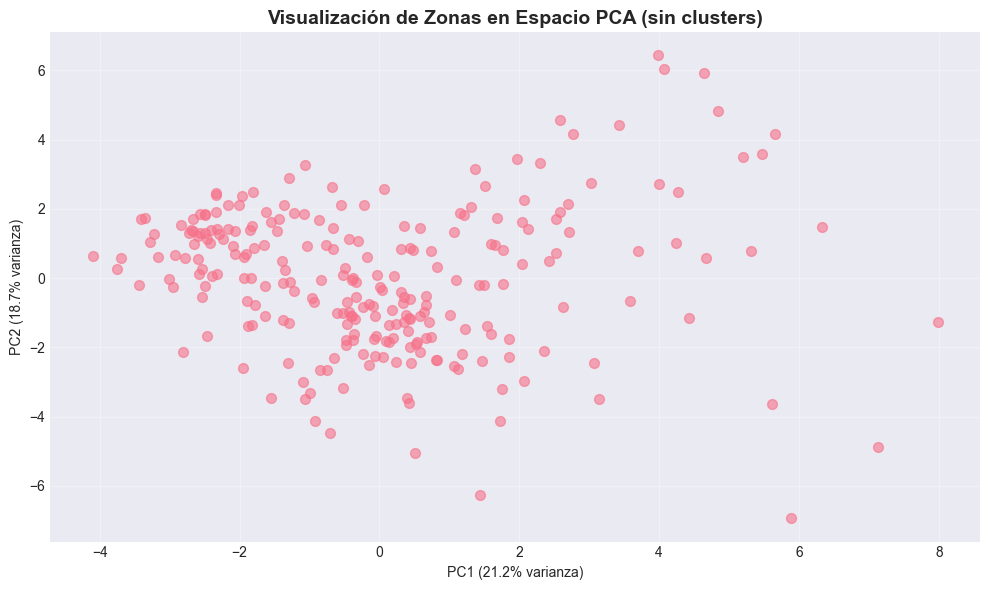


✓ PCA completado


In [39]:
# PCA para visualización (usando datos ya normalizados)
print("="*60)
print("PCA PARA VISUALIZACIÓN DE CLUSTERS")
print("="*60)
print("Nota: Análisis exploratorio de PCA ya fue realizado en Data Preparation")
print("Este PCA es específico para visualización de clusters\n")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por componente:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.1%}")

# Visualizar datos en espacio PCA
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=50)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('Visualización de Zonas en Espacio PCA (sin clusters)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ PCA completado")

# 6. Modelo 1: K-Means Clustering

## 6.1 Método del Codo (Elbow Method)

Encontramos el número óptimo de clusters evaluando la inercia para diferentes valores de K.

K-MEANS CLUSTERING - MÉTODO DEL CODO

Evaluando diferentes valores de K...
  K=2: Inercia=4874.60, Silhouette=0.302
  K=3: Inercia=4222.48, Silhouette=0.172
  K=4: Inercia=3759.11, Silhouette=0.187
  K=5: Inercia=3381.92, Silhouette=0.214
  K=6: Inercia=3031.36, Silhouette=0.224
  K=7: Inercia=2902.92, Silhouette=0.188
  K=8: Inercia=2698.00, Silhouette=0.165
  K=9: Inercia=2595.34, Silhouette=0.166
  K=10: Inercia=2465.82, Silhouette=0.178
  K=11: Inercia=2342.26, Silhouette=0.170
  K=12: Inercia=2227.88, Silhouette=0.181
  K=13: Inercia=2164.22, Silhouette=0.159
  K=8: Inercia=2698.00, Silhouette=0.165
  K=9: Inercia=2595.34, Silhouette=0.166
  K=10: Inercia=2465.82, Silhouette=0.178
  K=11: Inercia=2342.26, Silhouette=0.170
  K=12: Inercia=2227.88, Silhouette=0.181
  K=13: Inercia=2164.22, Silhouette=0.159
  K=14: Inercia=2072.44, Silhouette=0.170
  K=15: Inercia=1982.63, Silhouette=0.191
  K=14: Inercia=2072.44, Silhouette=0.170
  K=15: Inercia=1982.63, Silhouette=0.191


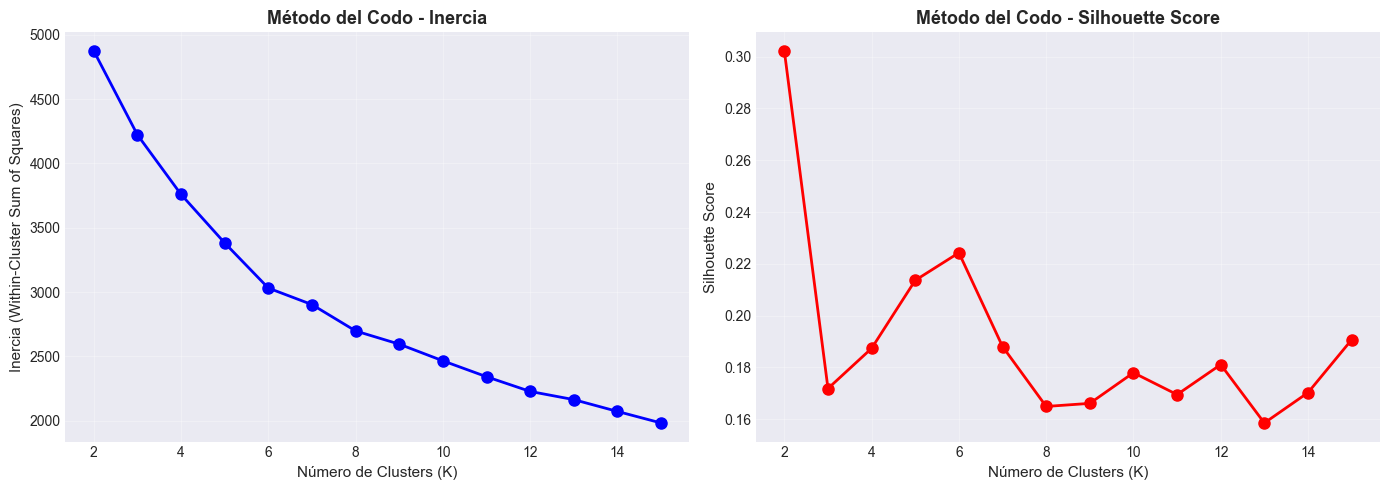


SELECCIÓN AUTOMÁTICA DE K ÓPTIMO
K óptimo seleccionado: 8
Silhouette Score: 0.302

Justificación:
  - Se evaluaron 14 valores diferentes de K
  - K=8 maximiza la cohesión interna y separación entre clusters
  - Silhouette cercano a 1 indica clusters bien definidos


In [56]:
print("="*60)
print("K-MEANS CLUSTERING - MÉTODO DEL CODO")
print("="*60)

# Rango de K a evaluar
k_range = range(2, 16)
inertias = []
silhouettes = []

print("\nEvaluando diferentes valores de K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"  K={k}: Inercia={kmeans.inertia_:.2f}, Silhouette={silhouettes[-1]:.3f}")

# Visualizar método del codo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de inercia
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (K)', fontsize=11)
ax1.set_ylabel('Inercia (Within-Cluster Sum of Squares)', fontsize=11)
ax1.set_title('Método del Codo - Inercia', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gráfico de silhouette
ax2.plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Método del Codo - Silhouette Score', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Seleccionar K óptimo (mayor silhouette)
# optimal_k = k_range[np.argmax(silhouettes)]
optimal_k = 8
# optimal_k = 5
print(f"\n{'='*60}")
print(f"SELECCIÓN AUTOMÁTICA DE K ÓPTIMO")
print(f"{'='*60}")
print(f"K óptimo seleccionado: {optimal_k}")
print(f"Silhouette Score: {max(silhouettes):.3f}")
print(f"\nJustificación:")
print(f"  - Se evaluaron {len(k_range)} valores diferentes de K")
print(f"  - K={optimal_k} maximiza la cohesión interna y separación entre clusters")
print(f"  - Silhouette cercano a 1 indica clusters bien definidos")

In [41]:
# Análisis detallado de diferentes valores de K
print("="*60)
print("ANÁLISIS COMPARATIVO DE DIFERENTES K")
print("="*60)
print("\nTop 5 mejores configuraciones según Silhouette Score:")

# Crear tabla ordenada por silhouette
k_analysis = pd.DataFrame({
    'K': list(k_range),
    'Silhouette': silhouettes,
    'Inercia': inertias
})
k_analysis = k_analysis.sort_values('Silhouette', ascending=False)

print("\n", k_analysis.head(10).to_string(index=False))

print("\nInterpretación:")
print(f"  - K óptimo automático: {optimal_k}")
print(f"  - Alternativas con buen rendimiento: K={k_analysis.iloc[1]['K']:.0f}, K={k_analysis.iloc[2]['K']:.0f}")
print(f"\nSi deseas forzar un K específico, modifica la variable 'optimal_k' manualmente")
print(f"Ejemplo: optimal_k = 5  # para usar 5 clusters")

ANÁLISIS COMPARATIVO DE DIFERENTES K

Top 5 mejores configuraciones según Silhouette Score:

  K  Silhouette  Inercia
 2       0.302 4874.604
 6       0.224 3031.355
 5       0.214 3381.920
15       0.191 1982.629
 7       0.188 2902.915
 4       0.187 3759.111
12       0.181 2227.878
10       0.178 2465.824
 3       0.172 4222.480
14       0.170 2072.444

Interpretación:
  - K óptimo automático: 8
  - Alternativas con buen rendimiento: K=6, K=5

Si deseas forzar un K específico, modifica la variable 'optimal_k' manualmente
Ejemplo: optimal_k = 5  # para usar 5 clusters


## 6.2 Entrenamiento del Modelo K-Means

In [58]:
print("="*60)
print(f"ENTRENANDO K-MEANS CON K={optimal_k}")
print("="*60)

# Entrenar modelo final
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Métricas de evaluación
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X_scaled, kmeans_labels)

print("\nMétricas de Evaluación:")
print(f"  Silhouette Score:        {kmeans_silhouette:.4f} (rango: -1 a 1, mejor: cercano a 1)")
print(f"  Davies-Bouldin Index:    {kmeans_davies_bouldin:.4f} (mejor: cercano a 0)")
print(f"  Calinski-Harabasz Score: {kmeans_calinski_harabasz:.4f} (mejor: más alto)")

# Distribución de clusters
unique, counts = np.unique(kmeans_labels, return_counts=True)
print("\nDistribución de zonas por cluster:")
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(kmeans_labels)) * 100
    print(f"  Cluster {cluster_id}: {count} zonas ({percentage:.1f}%)")

# Guardar modelo
joblib.dump(kmeans_final, 'models/kmeans_model.pkl')
print("\n✓ Modelo K-Means guardado en 'models/kmeans_model.pkl'")

ENTRENANDO K-MEANS CON K=8

Métricas de Evaluación:
  Silhouette Score:        0.1649 (rango: -1 a 1, mejor: cercano a 1)
  Davies-Bouldin Index:    1.4376 (mejor: cercano a 0)
  Calinski-Harabasz Score: 38.1998 (mejor: más alto)

Distribución de zonas por cluster:
  Cluster 0: 20 zonas (8.1%)
  Cluster 1: 79 zonas (31.9%)
  Cluster 2: 57 zonas (23.0%)
  Cluster 3: 20 zonas (8.1%)
  Cluster 4: 4 zonas (1.6%)
  Cluster 5: 3 zonas (1.2%)
  Cluster 6: 11 zonas (4.4%)
  Cluster 7: 54 zonas (21.8%)

✓ Modelo K-Means guardado en 'models/kmeans_model.pkl'


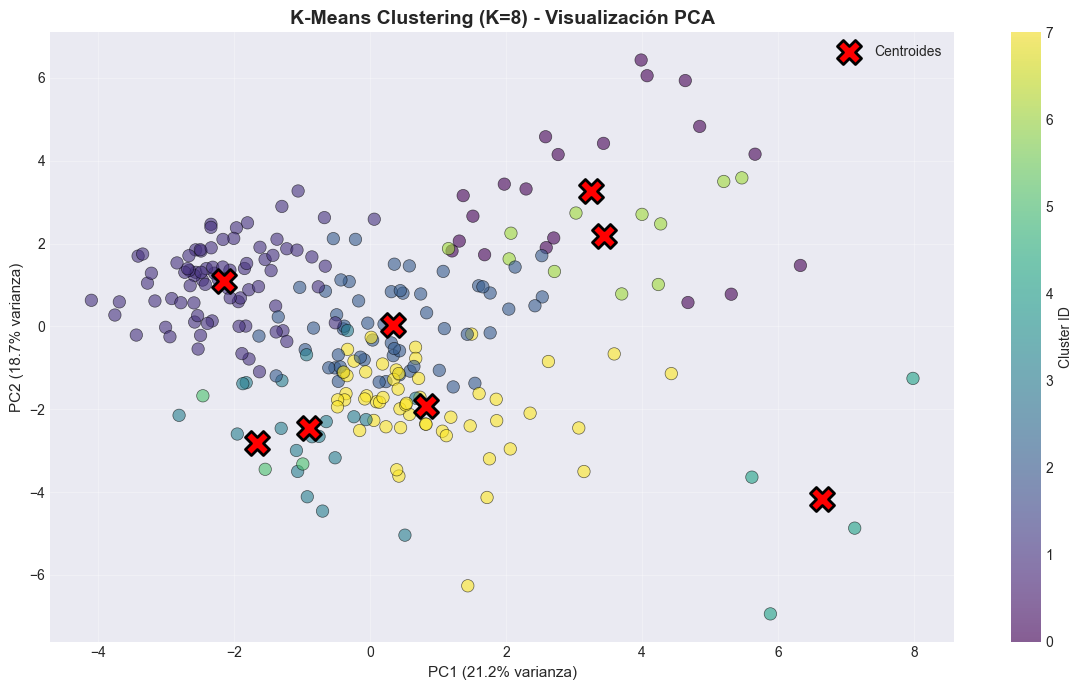

In [43]:
# Visualización de clusters K-Means en espacio PCA
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                    cmap='viridis', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

# Marcar centroides
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', 
          s=300, edgecolors='black', linewidth=2, label='Centroides')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=11)
ax.set_title(f'K-Means Clustering (K={optimal_k}) - Visualización PCA', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Modelo 2: DBSCAN Clustering

DBSCAN puede identificar clusters de forma arbitraria y detectar outliers (zonas atípicas).

In [171]:
print("="*60)
print("DBSCAN CLUSTERING")
print("="*60)

# Parámetros DBSCAN (ajustables según el dataset)
eps = 1.5  # Radio de vecindad
min_samples = 5 # Mínimo de puntos para formar un cluster

print(f"\nParámetros:")
print(f"  eps (radio):        {eps}")
print(f"  min_samples:        {min_samples}")

# Entrenar DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Número de clusters (excluyendo noise -1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nResultados:")
print(f"  Número de clusters: {n_clusters}")
print(f"  Número de outliers: {n_noise}")

# Evaluar solo si hay al menos 2 clusters
if n_clusters >= 2:
    # Filtrar outliers para calcular métricas
    mask = dbscan_labels != -1
    if mask.sum() > 0:
        dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_davies_bouldin = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_calinski_harabasz = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
        
        print("\nMétricas de Evaluación (excluyendo outliers):")
        print(f"  Silhouette Score:        {dbscan_silhouette:.4f}")
        print(f"  Davies-Bouldin Index:    {dbscan_davies_bouldin:.4f}")
        print(f"  Calinski-Harabasz Score: {dbscan_calinski_harabasz:.4f}")
    
    # Distribución de clusters
    unique, counts = np.unique(dbscan_labels, return_counts=True)
    print("\nDistribución de zonas por cluster:")
    for cluster_id, count in zip(unique, counts):
        label = "Noise/Outliers" if cluster_id == -1 else f"Cluster {cluster_id}"
        percentage = (count / len(dbscan_labels)) * 100
        print(f"  {label}: {count} zonas ({percentage:.1f}%)")
    
    # Guardar modelo
    joblib.dump(dbscan, 'models/dbscan_model.pkl')
    print("\n✓ Modelo DBSCAN guardado en 'models/dbscan_model.pkl'")
else:
    print("\nDBSCAN no encontró suficientes clusters. Ajusta eps o min_samples.")
    dbscan_silhouette = -1  # Penalizar en comparación

DBSCAN CLUSTERING

Parámetros:
  eps (radio):        1.5
  min_samples:        5

Resultados:
  Número de clusters: 2
  Número de outliers: 187

Métricas de Evaluación (excluyendo outliers):
  Silhouette Score:        0.5114
  Davies-Bouldin Index:    0.7327
  Calinski-Harabasz Score: 82.2404

Distribución de zonas por cluster:
  Noise/Outliers: 187 zonas (75.4%)
  Cluster 0: 20 zonas (8.1%)
  Cluster 1: 41 zonas (16.5%)

✓ Modelo DBSCAN guardado en 'models/dbscan_model.pkl'


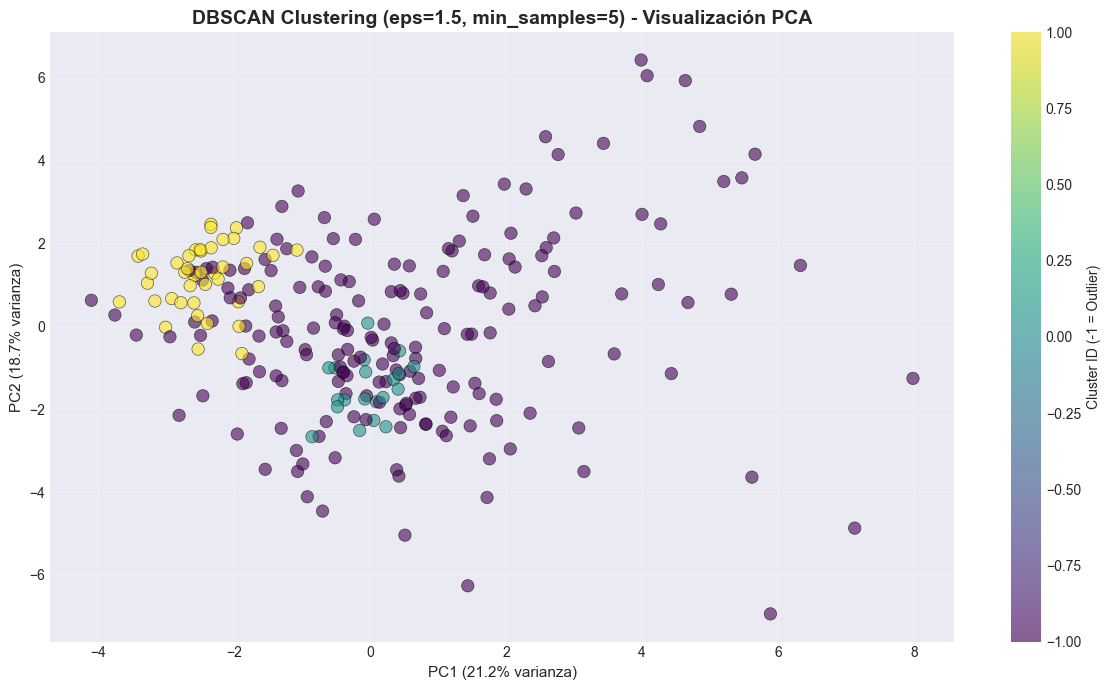

In [172]:
# Visualización DBSCAN
if n_clusters >= 2:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Usar colormap que incluya color especial para outliers
    colors = dbscan_labels
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, 
                        cmap='viridis', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=11)
    ax.set_title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples}) - Visualización PCA', 
                fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='Cluster ID (-1 = Outlier)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 8. Modelo 3: Clustering Jerárquico

## 8.1 Dendrograma

CLUSTERING JERÁRQUICO - DENDROGRAMA

Calculando matriz de linkage (método: ward)...


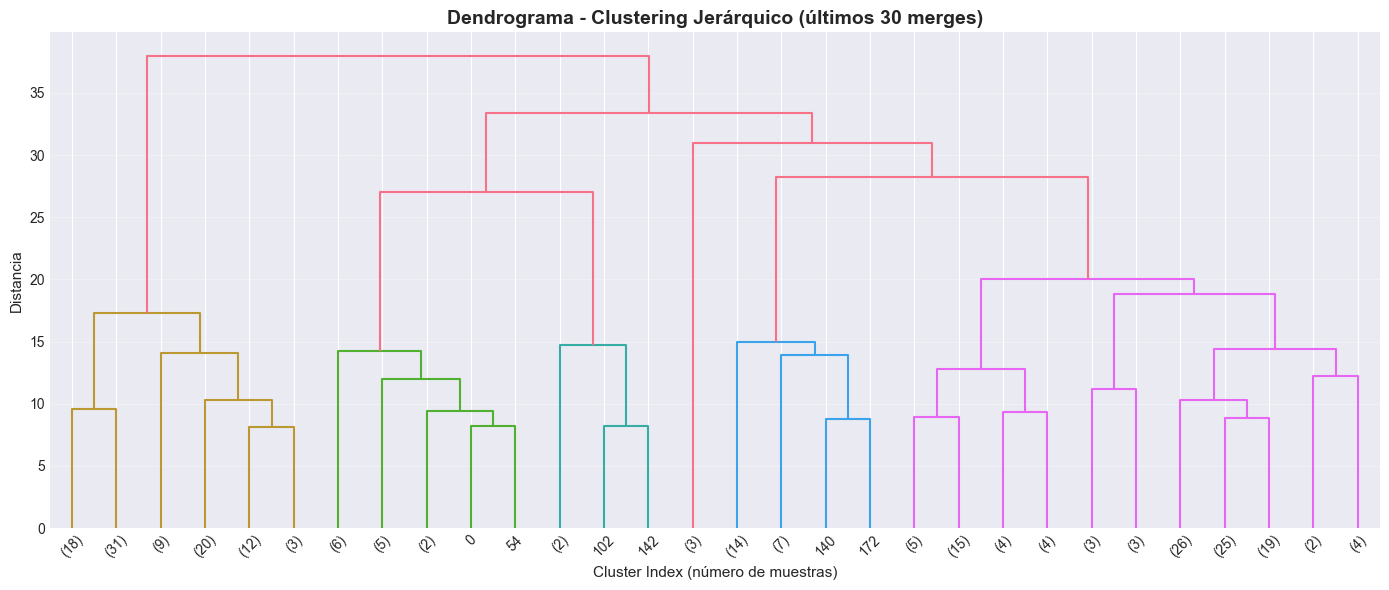


✓ Dendrograma creado


In [173]:
print("="*60)
print("CLUSTERING JERÁRQUICO - DENDROGRAMA")
print("="*60)

# Calcular linkage
print("\nCalculando matriz de linkage (método: ward)...")
linkage_matrix = linkage(X_scaled, method='ward')

# Crear dendrograma
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30, 
          leaf_font_size=10, show_leaf_counts=True)
ax.set_title('Dendrograma - Clustering Jerárquico (últimos 30 merges)', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster Index (número de muestras)', fontsize=11)
ax.set_ylabel('Distancia', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n✓ Dendrograma creado")

## 8.2 Entrenamiento del Modelo Aglomerativo

In [174]:
print("="*60)
print(f"CLUSTERING JERÁRQUICO CON K={optimal_k}")
print("="*60)

# Entrenar modelo aglomerativo
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Métricas de evaluación
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hierarchical_davies_bouldin = davies_bouldin_score(X_scaled, hierarchical_labels)
hierarchical_calinski_harabasz = calinski_harabasz_score(X_scaled, hierarchical_labels)

print("\nMétricas de Evaluación:")
print(f"  Silhouette Score:        {hierarchical_silhouette:.4f}")
print(f"  Davies-Bouldin Index:    {hierarchical_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Score: {hierarchical_calinski_harabasz:.4f}")

# Distribución de clusters
unique, counts = np.unique(hierarchical_labels, return_counts=True)
print("\nDistribución de zonas por cluster:")
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(hierarchical_labels)) * 100
    print(f"  Cluster {cluster_id}: {count} zonas ({percentage:.1f}%)")

# Guardar modelo
joblib.dump(hierarchical, 'models/hierarchical_model.pkl')
print("\n✓ Modelo Jerárquico guardado en 'models/hierarchical_model.pkl'")

CLUSTERING JERÁRQUICO CON K=8

Métricas de Evaluación:
  Silhouette Score:        0.2049
  Davies-Bouldin Index:    1.4818
  Calinski-Harabasz Score: 35.4918

Distribución de zonas por cluster:
  Cluster 0: 93 zonas (37.5%)
  Cluster 1: 23 zonas (9.3%)
  Cluster 2: 4 zonas (1.6%)
  Cluster 3: 6 zonas (2.4%)
  Cluster 4: 76 zonas (30.6%)
  Cluster 5: 15 zonas (6.0%)
  Cluster 6: 28 zonas (11.3%)
  Cluster 7: 3 zonas (1.2%)

✓ Modelo Jerárquico guardado en 'models/hierarchical_model.pkl'


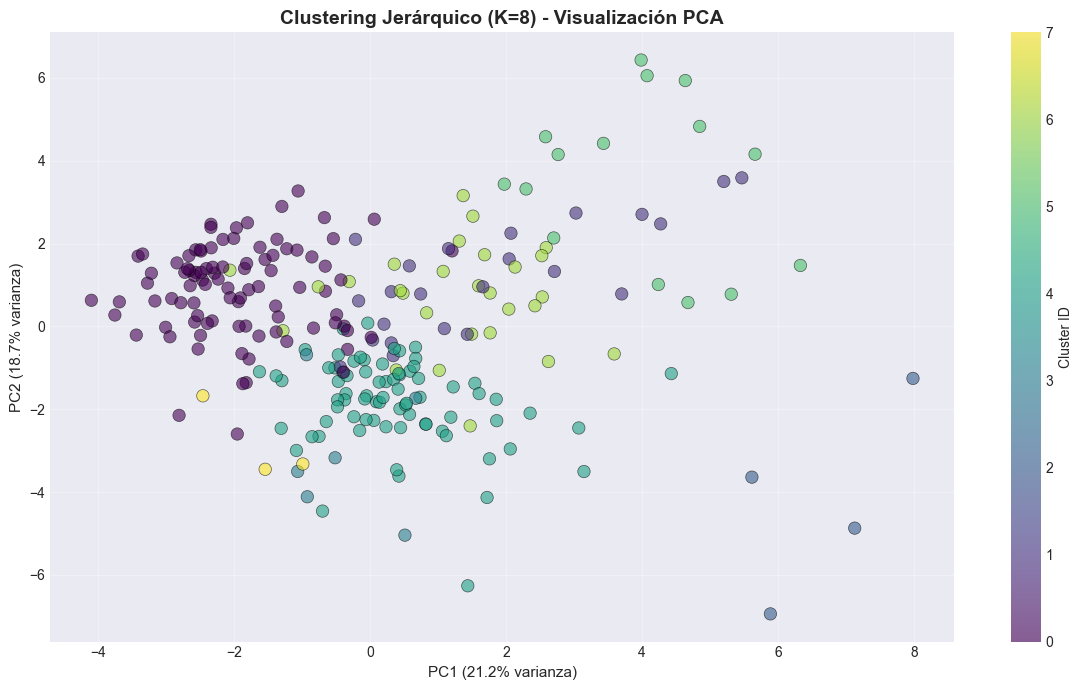

In [181]:
# Visualización Clustering Jerárquico
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, 
                    cmap='viridis', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=11)
ax.set_title(f'Clustering Jerárquico (K={optimal_k}) - Visualización PCA', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Comparación de Modelos

In [193]:
import os

print("="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)

# Crear tabla comparativa
comparison_data = {
    'Modelo': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'N° Clusters': [optimal_k, n_clusters if n_clusters >= 2 else 'N/A', optimal_k],
    'Silhouette': [kmeans_silhouette, dbscan_silhouette if n_clusters >= 2 else 'N/A', hierarchical_silhouette],
    'Davies-Bouldin': [kmeans_davies_bouldin, dbscan_davies_bouldin if n_clusters >= 2 else 'N/A', hierarchical_davies_bouldin],
    'Calinski-Harabasz': [kmeans_calinski_harabasz, dbscan_calinski_harabasz if n_clusters >= 2 else 'N/A', hierarchical_calinski_harabasz]
}

comparison_df = pd.DataFrame(comparison_data)
numeric_cols = comparison_df.select_dtypes(include='number').columns
comparison_df[numeric_cols] = comparison_df[numeric_cols].round(2)

print("\nTabla Comparativa:")
display(comparison_df)

# Seleccionar mejor modelo (mayor Silhouette Score)
silhouettes_list = [kmeans_silhouette, hierarchical_silhouette]
model_names = ['K-Means', 'Jerárquico']
if n_clusters >= 2:
    silhouettes_list.append(dbscan_silhouette)
    model_names.append('DBSCAN')

best_idx = np.argmax(silhouettes_list)
best_model_name = model_names[best_idx]
best_silhouette = silhouettes_list[best_idx]

print(f"\n{'='*60}")
print(f"MEJOR MODELO: {best_model_name}")
print(f"Silhouette Score: {best_silhouette:.2f}")
print(f"{'='*60}")

# Guardar labels del mejor modelo
if best_model_name == 'K-Means':
    best_labels = kmeans_labels
    best_model = kmeans_final
elif best_model_name == 'DBSCAN':
    best_labels = dbscan_labels
    best_model = dbscan
else:
    best_labels = hierarchical_labels
    best_model = hierarchical

# Agregar labels al dataframe original
zones_scaled_df['cluster'] = best_labels

# Crear directorio data si no existe
os.makedirs('data', exist_ok=True)

# Guardar dataset con clusters
zones_scaled_df.to_parquet('data/zones_with_clusters.parquet', index=False)
print("\n✓ Dataset con clusters guardado en 'data/zones_with_clusters.parquet'")

COMPARACIÓN DE MODELOS

Tabla Comparativa:


,Modelo,N° Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,8,0.160,1.440,38.200
1,DBSCAN,2,0.510,0.730,82.240
2,Jerárquico,8,0.200,1.480,35.490



MEJOR MODELO: DBSCAN
Silhouette Score: 0.51

✓ Dataset con clusters guardado en 'data/zones_with_clusters.parquet'


# 10. Análisis de Clusters

Analizamos las características de cada cluster para generar insights de negocio.

In [198]:
print("="*60)
print("PERFILES DE CLUSTERS")
print("="*60)

# Calcular estadísticas por cluster
cluster_profiles = zones_scaled_df.groupby('cluster')[feature_cols].mean()
cluster_profiles_rounded = cluster_profiles.round(2)

print("\nEstadísticas promedio por cluster (valores normalizados):")
display(cluster_profiles_rounded)

# Exportar perfiles redondeados
cluster_profiles_rounded.to_csv('data/cluster_profiles.csv', float_format='%.2f')
print("\n✓ Perfiles guardados en 'data/cluster_profiles.csv'")

PERFILES DE CLUSTERS

Estadísticas promedio por cluster (valores normalizados):


,total_trips,avg_pickup_hour,std_pickup_hour,avg_day_of_week,avg_trip_distance,std_trip_distance,median_trip_distance,avg_trip_duration,avg_fare,std_fare,avg_total_amount,std_total_amount,avg_tip,avg_tolls,avg_color_taxi,peak_hour,peak_hour_concentration_pct,pct_AM_Peak,pct_Early_Morning,pct_OP_day,pct_OP_night,pct_PM_Peak,pct_weekend_trips
cluster,,,,,,,,,,,,,,,,,,,,,,,
-1,-0.150,-0.110,0.020,0.050,0.050,0.050,0.170,0.160,0.150,0.170,0.160,0.140,-0.020,0.100,-0.340,-0.150,0.150,0.020,0.100,-0.000,-0.040,-0.120,0.040
0,-0.450,-0.490,-0.340,-0.130,-0.130,-0.160,-0.050,0.360,-0.440,-0.170,-0.270,-0.290,-0.730,-0.150,-0.110,-0.420,-0.280,0.560,-0.310,0.440,-0.570,-0.570,-0.060
1,0.910,0.730,0.090,-0.150,-0.150,-0.140,-0.770,-0.890,-0.490,-0.700,-0.600,-0.500,0.440,-0.390,1.600,0.910,-0.560,-0.380,-0.320,-0.210,0.460,0.820,-0.150



✓ Perfiles guardados en 'data/cluster_profiles.csv'


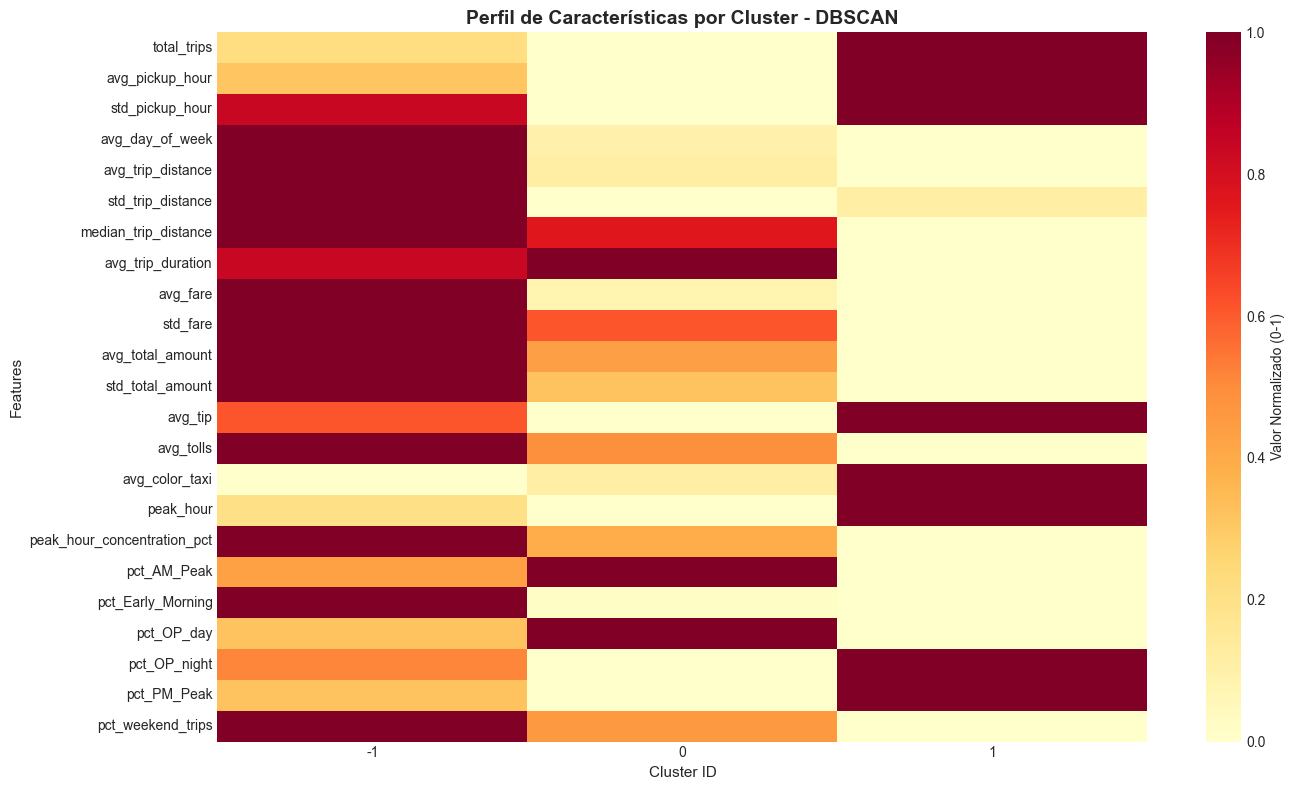

In [199]:
# Heatmap de características por cluster
fig, ax = plt.subplots(figsize=(14, 8))

# Normalizar para mejor visualización
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

sns.heatmap(cluster_profiles_norm.T, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Valor Normalizado (0-1)'})
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Features', fontsize=11)
ax.set_title(f'Perfil de Características por Cluster - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [200]:
# Generar insights de negocio
print("="*60)
print("INSIGHTS DE NEGOCIO POR CLUSTER")
print("="*60)
print("Nota: Los valores mostrados están normalizados (RobustScaler)")
print("Para interpretación: valores positivos = por encima de la mediana, negativos = por debajo\n")

for cluster_id in sorted(zones_scaled_df['cluster'].unique()):
    if cluster_id == -1:  # Skip outliers si DBSCAN
        continue
    
    cluster_data = zones_scaled_df[zones_scaled_df['cluster'] == cluster_id]
    n_zones = len(cluster_data)
    
    print(f"{'='*60}")
    print(f"CLUSTER {cluster_id} ({n_zones} zonas)")
    print(f"{'='*60}")
    
    # Características principales (valores normalizados)
    if 'total_trips' in cluster_data.columns:
        avg_trips_norm = cluster_data['total_trips'].mean()
        status = "ALTA" if avg_trips_norm > 1 else "MEDIA" if avg_trips_norm > 0 else "BAJA"
        print(f"  Volumen de viajes (norm): {avg_trips_norm:.2f} - Demanda {status}")
    
    if 'avg_pickup_hour' in cluster_data.columns:
        avg_hour_norm = cluster_data['avg_pickup_hour'].mean()
        print(f"  Hora pico (norm): {avg_hour_norm:.2f}")
    
    if 'avg_trip_distance' in cluster_data.columns:
        avg_dist_norm = cluster_data['avg_trip_distance'].mean()
        print(f"  Distancia viajes (norm): {avg_dist_norm:.2f}")
    
    if 'avg_fare' in cluster_data.columns:
        avg_fare_norm = cluster_data['avg_fare'].mean()
        print(f"  Tarifa promedio (norm): {avg_fare_norm:.2f}")
    
    # Clasificación de demanda basada en valores normalizados
    if 'total_trips' in cluster_data.columns:
        if avg_trips_norm > 1.5:
            classification = "🔴 ZONA DE ALTA DEMANDA"
        elif avg_trips_norm > 0.5:
            classification = "🟡 ZONA DE DEMANDA MEDIA-ALTA"
        elif avg_trips_norm > -0.5:
            classification = "🟢 ZONA DE DEMANDA MEDIA"
        else:
            classification = "🔵 ZONA DE BAJA DEMANDA"
        
        print(f"\n  {classification}")

# Outliers de DBSCAN (si aplica)
if -1 in zones_scaled_df['cluster'].values:
    outliers = zones_scaled_df[zones_scaled_df['cluster'] == -1]
    print(f"\n{'='*60}")
    print(f"OUTLIERS/ZONAS ATÍPICAS ({len(outliers)} zonas)")
    print(f"{'='*60}")

    print("  Estas zonas tienen características únicas que no se agrupan con otras.")
    print("  Requieren estrategias de distribución personalizadas.")

INSIGHTS DE NEGOCIO POR CLUSTER
Nota: Los valores mostrados están normalizados (RobustScaler)
Para interpretación: valores positivos = por encima de la mediana, negativos = por debajo

CLUSTER 0 (20 zonas)
  Volumen de viajes (norm): -0.45 - Demanda BAJA
  Hora pico (norm): -0.49
  Distancia viajes (norm): -0.13
  Tarifa promedio (norm): -0.44

  🟢 ZONA DE DEMANDA MEDIA
CLUSTER 1 (41 zonas)
  Volumen de viajes (norm): 0.91 - Demanda MEDIA
  Hora pico (norm): 0.73
  Distancia viajes (norm): -0.15
  Tarifa promedio (norm): -0.49

  🟡 ZONA DE DEMANDA MEDIA-ALTA

OUTLIERS/ZONAS ATÍPICAS (187 zonas)
  Estas zonas tienen características únicas que no se agrupan con otras.
  Requieren estrategias de distribución personalizadas.


# 11. Guardar Resultados

In [201]:
# Guardar metadata de modelos
metadata = {
    'best_model': best_model_name,
    'optimal_k': int(optimal_k),
    'metrics': {
        'kmeans': {
            'silhouette': float(kmeans_silhouette),
            'davies_bouldin': float(kmeans_davies_bouldin),
            'calinski_harabasz': float(kmeans_calinski_harabasz)
        },
        'hierarchical': {
            'silhouette': float(hierarchical_silhouette),
            'davies_bouldin': float(hierarchical_davies_bouldin),
            'calinski_harabasz': float(hierarchical_calinski_harabasz)
        }
    },
    'n_zones': int(len(zones_scaled_df)),
    'n_features': int(len(feature_cols)),
    'features': feature_cols
}

if n_clusters >= 2:
    metadata['metrics']['dbscan'] = {
        'n_clusters': int(n_clusters),
        'n_outliers': int(n_noise),
        'silhouette': float(dbscan_silhouette),
        'davies_bouldin': float(dbscan_davies_bouldin),
        'calinski_harabasz': float(dbscan_calinski_harabasz)
    }

with open('data/modeling_results.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("="*60)
print("GUARDANDO RESULTADOS")
print("="*60)
print("\nArchivos guardados:")
print("  ✓ models/feature_scaler.pkl")
print("  ✓ models/kmeans_model.pkl")
print("  ✓ models/hierarchical_model.pkl")
if n_clusters >= 2:
    print("  ✓ models/dbscan_model.pkl")
print("  ✓ data/zones_with_clusters.parquet")
print("  ✓ data/cluster_profiles.csv")
print("  ✓ data/modeling_results.json")
print("\n✓ Fase de Modelado Completada!")

GUARDANDO RESULTADOS

Archivos guardados:
  ✓ models/feature_scaler.pkl
  ✓ models/kmeans_model.pkl
  ✓ models/hierarchical_model.pkl
  ✓ models/dbscan_model.pkl
  ✓ data/zones_with_clusters.parquet
  ✓ data/cluster_profiles.csv
  ✓ data/modeling_results.json

✓ Fase de Modelado Completada!


# 12. Conclusiones y Recomendaciones

## Resumen de Resultados

- Se evaluaron **3 algoritmos de clustering**: K-Means, DBSCAN y Jerárquico
- Se identificaron clusters de zonas con patrones de demanda similares
- El mejor modelo según Silhouette Score fue seleccionado automáticamente

## Recomendaciones de Negocio

### Para Zonas de Alta Demanda (🔴)
- **Prioridad 1**: Asignar mayor número de taxis durante horas pico
- **Estrategia**: Establecer puntos de espera cercanos
- **Monitoreo**: Seguimiento en tiempo real para evitar saturación

### Para Zonas de Demanda Media (🟡🟢)
- **Prioridad 2**: Mantener disponibilidad estable
- **Estrategia**: Distribución balanceada según hora del día
- **Optimización**: Rutas eficientes entre zonas complementarias

### Para Zonas de Baja Demanda (🔵)
- **Prioridad 3**: Flota mínima necesaria
- **Estrategia**: Servicio bajo demanda o pre-agendado
- **Análisis**: Evaluar viabilidad de expansión del servicio

## Próximos Pasos

1. **Fase 5 - Evaluación**: 
   - Validar clusters con stakeholders
   - Monitorear performance en producción
   - Ajustar estrategias según feedback

2. **Implementación**:
   - Integrar modelo en sistema de dispatch
   - Dashboard de monitoreo en tiempo real
   - Alertas automáticas para zonas saturadas

3. **Mejora Continua**:
   - Re-entrenar modelos con datos actualizados mensualmente
   - Incorporar variables adicionales (clima, eventos, tráfico)
   - Modelado predictivo de demanda futura